ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [ ]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

***Ans_1:*** We know, 2nd quartile is median which is 50 percentile. So,

median = np.percentile(data,50)

IQR is the difference of 3rd and 1st quartile. So,

iqr = q3 - q1

Final Answer:
IQR: 2.0,
Median: 33.0

***Ans_2***

lower_fence = q1 - (1.5*iqr)

upper_fence = q3 + (1.5*iqr)

here, lower fence is 29 and upper fence is 37. 500 is out of this range. So, 500 is outlier

***Ans_3:***

For this dataset, there is an extreme outlier(500) which effects the mean and standard deviation value. On the other hand, Median and IQR remain close to the central cluster around the value of 30-35. Using median + IQR gives a more accurate picture of the true distribution of most data points.

In [ ]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33] # [ 30  31  32  32  33  33  34  34  35 500]
data = np.array(data_q1)

q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1

print(f'IQR: {iqr}')
print(f'Median: {q2}')

# IQR rule
lower_fence = q1 - (1.5*iqr)
upper_fence = q3 + (1.5*iqr)

print(f'Lower fence: {lower_fence}')
print(f'Upper fence: {upper_fence}')

IQR: 2.0
Median: 33.0
Lower fence: 29.0
Upper fence: 37.0


### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

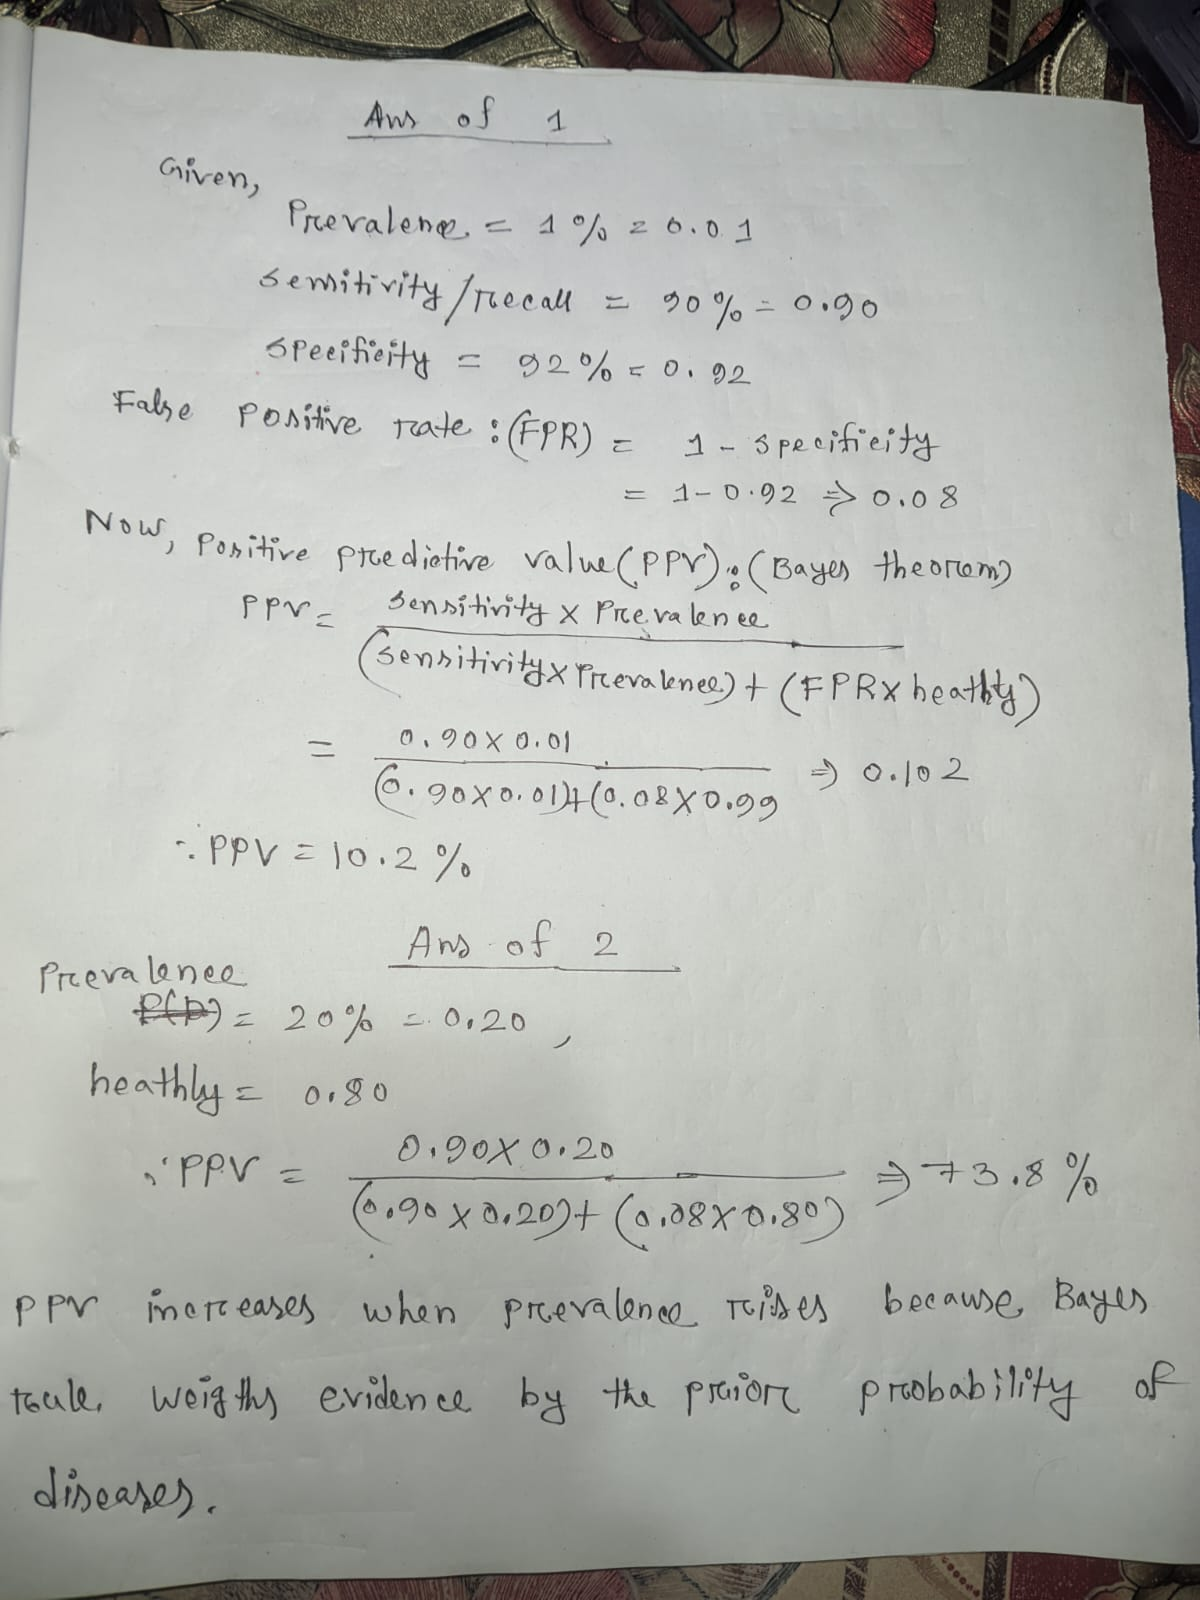

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

***Task type:***
This is a binary classification task because the target variable premium_user is 0 or 1.

***Preprocessing List:***

1. Handle missing values of age and daily clicks
2. Encode region using OneHotEncoding
3. Scale the numeric features(age and daily_clicks) using Standardization and normalization.
4. Split data into training and test sets    

***ML pipeline:***
I would clean the data, handle missing values, and encode the categorical column. Then I would scale the numeric features and split the dataset into train and test sets. After preprocessing, I would train a suitable classification model and evaluate it using metrics like accuracy, precision, recall, and AUC. Finally, I would tune hyperparameters if needed and review the results to ensure the model performs well.

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [ ]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


In [ ]:
# Compact EDA using pandas
print('Missing value summary: ')
df.isnull().sum()

Missing value summary: 


,0
age,2
region,0
purchases,1
premium_user,0


In [ ]:
print('Number of unique values: ')
df.nunique()

Number of unique values: 


,0
age,5
region,4
purchases,6
premium_user,2


In [ ]:
print('Correlation among numeric columns: ')

df[['age','purchases','premium_user']].corr()

Correlation among numeric columns: 


,age,purchases,premium_user
age,1.000000,0.923677,0.789534
purchases,0.923677,1.000000,0.825860
premium_user,0.789534,0.825860,1.000000


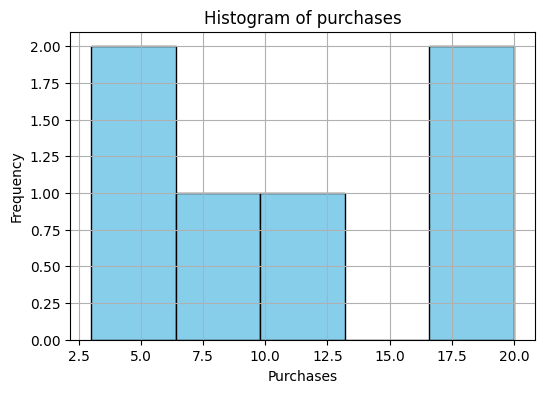

In [ ]:
# Histogram of purchases
plt.figure(figsize=(6,4))
df['purchases'].hist(bins=5, color='skyblue', edgecolor='black')
plt.title('Histogram of purchases')
plt.xlabel('Purchases')
plt.ylabel('Frequency')
plt.show()

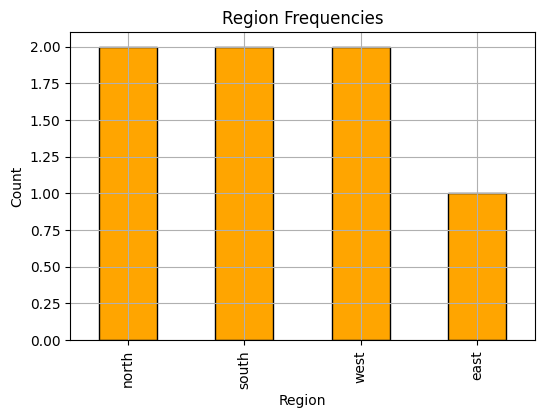

In [ ]:
# Bar chart for region frequencies
plt.figure(figsize=(6,4))
df['region'].value_counts().plot(kind='bar',color='orange', edgecolor='black')
plt.title('Region Frequencies')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Preprocess the dataset using sklearn plus pandas
X = df.drop('premium_user', axis=1)
y = df['premium_user']

numeric_cols = ['age', 'purchases']
categorical_cols = ['region']

# preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # for age
    ('scaler', RobustScaler())
])

numeric_transformer_purchases = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine transformation
preprocessor = ColumnTransformer(
    transformers=[
        ('age', numeric_transformer, ['age']),
        ('purchases', numeric_transformer_purchases, ['purchases']),
        ('region', categorical_transformer, ['region'])
    ]
)

X_preprocessed = preprocessor.fit_transform(X)


ohe_cols = preprocessor.named_transformers_['region']['onehot'].get_feature_names_out(['region'])
all_cols = ['age', 'purchases'] + list(ohe_cols)
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_cols)

X_preprocessed_df

,age,purchases,region_north,region_south,region_west
0,-0.5,-0.943820,1.0,0.0,0.0
1,0.0,0.000000,0.0,1.0,0.0
2,0.0,-0.674157,1.0,0.0,0.0
3,-0.8,0.112360,0.0,0.0,0.0
4,1.5,1.348315,0.0,0.0,1.0
5,2.2,1.078652,0.0,0.0,1.0
6,0.0,-0.134831,0.0,1.0,0.0


In [ ]:
# Creating one domain-driven-feature
X_preprocessed_df["high_spender"] = (df["purchases"] >= 15).astype(int)
final_df = X_preprocessed_df
final_df  # question 3 and 4 answer includes in this 3 line

,age,purchases,region_north,region_south,region_west,high_spender
0,-0.5,-0.943820,1.0,0.0,0.0,0
1,0.0,0.000000,0.0,1.0,0.0,0
2,0.0,-0.674157,1.0,0.0,0.0,0
3,-0.8,0.112360,0.0,0.0,0.0,0
4,1.5,1.348315,0.0,0.0,1.0,1
5,2.2,1.078652,0.0,0.0,1.0,1
6,0.0,-0.134831,0.0,1.0,0.0,0


_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [ ]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


In [ ]:
# step 2: split the dataset
X = df2[["area_sqft", "bedrooms"]]
y = df2["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# step 3: Fit linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# step 4: Print intercept, coefficients, and predictions
print(f'Intercept: {model.intercept_:.2f}')

coef = [f'{c:.2f}' for c in model.coef_]
print(f'Coefficients:  {coef[0]}', f'{coef[1]}')

y_pred = model.predict(X_test)
print('Predictions: ')
for c in y_pred:
  print(f'{c:.2f}')

Intercept: -33.85
Coefficients:  0.15 5.38
Predictions: 
100.00
130.77


In [ ]:
# step 5:
# Mean Absolute Error (MAE)
# Root Mean Squared Error (RMSE)
# R squared (R²)

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R^2: {r2:.2f}')

MAE: 19.62
RMSE: 19.62
R^2: -0.71


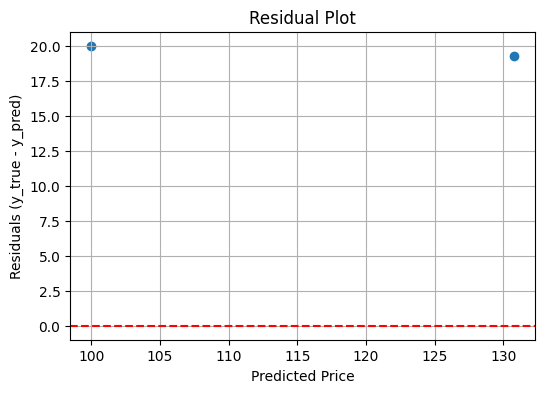

In [ ]:
# step 6: Residual plot

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot")
plt.show()

***Short Note:***

Residuals are scattered around zero without a clear pattern, suggesting the model fits reasonably well.  
If residuals showed a trend, it would indicate missing non-linear relationships or features.


_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [ ]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

In [ ]:
# Predictions at threshold 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

print("Confusion Matrix (0.5):\n", confusion_matrix(y_true, y_pred_05))
print("Precision (0.5):", precision_score(y_true, y_pred_05))
print("Recall (0.5):", recall_score(y_true, y_pred_05))
print("F1 Score (0.5):", f1_score(y_true, y_pred_05))

Confusion Matrix (0.5):
 [[5 0]
 [0 5]]
Precision (0.5): 1.0
Recall (0.5): 1.0
F1 Score (0.5): 1.0


In [ ]:
# Predictions at threshold 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

print("Confusion Matrix (0.3):\n", confusion_matrix(y_true, y_pred_03))
print("Precision (0.3):", precision_score(y_true, y_pred_03))
print("Recall (0.3):", recall_score(y_true, y_pred_03))
print("F1 Score (0.3):", f1_score(y_true, y_pred_03))


Confusion Matrix (0.3):
 [[3 2]
 [0 5]]
Precision (0.3): 0.7142857142857143
Recall (0.3): 1.0
F1 Score (0.3): 0.8333333333333334


***Short Explanation:***

Lowering the threshold from 0.5 to 0.3 increased recall (still perfect here) but reduced precision. This happens because more samples are classified as positive, catching all true positives but also introducing false positives. Precision drops since some negatives are now incorrectly labeled positive. In general, lowering the threshold favors recall at the expense of precision.

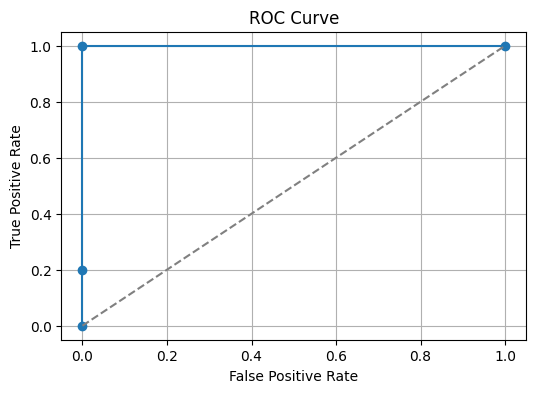

In [ ]:
# Plot Roc curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

plt.plot(fpr, tpr, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
print("AUC:", round(auc, 3))

AUC: 1.0


***Short Explanation:***

A high AUC (close to 1) means the model separates positives and negatives very well. A low AUC (close to 0.5) would mean the model is no better than random guessing.

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._

In [ ]:
# Fit the decision Tree
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Data
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

X = df3[["hours"]]
y = df3["passed"]

# Fit Decision Tree with max_depth=2
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

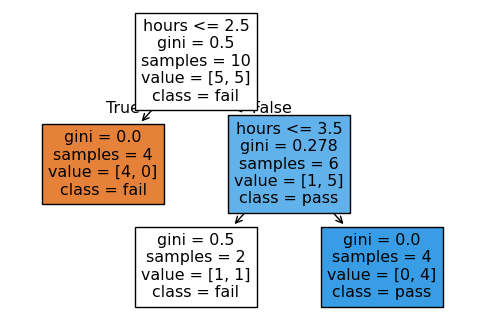

In [ ]:
# Plot the tree
plt.figure(figsize=(6,4))
plot_tree(clf, feature_names=["hours"], class_names=["fail","pass"], filled=True)
plt.show()

***Short Explanation:***

With only one feature (hours) and a shallow depth of 2, the tree is simple and unlikely to overfit. It captures the basic trend (more hours → higher chance of passing) while remaining general enough to apply beyond this small dataset.